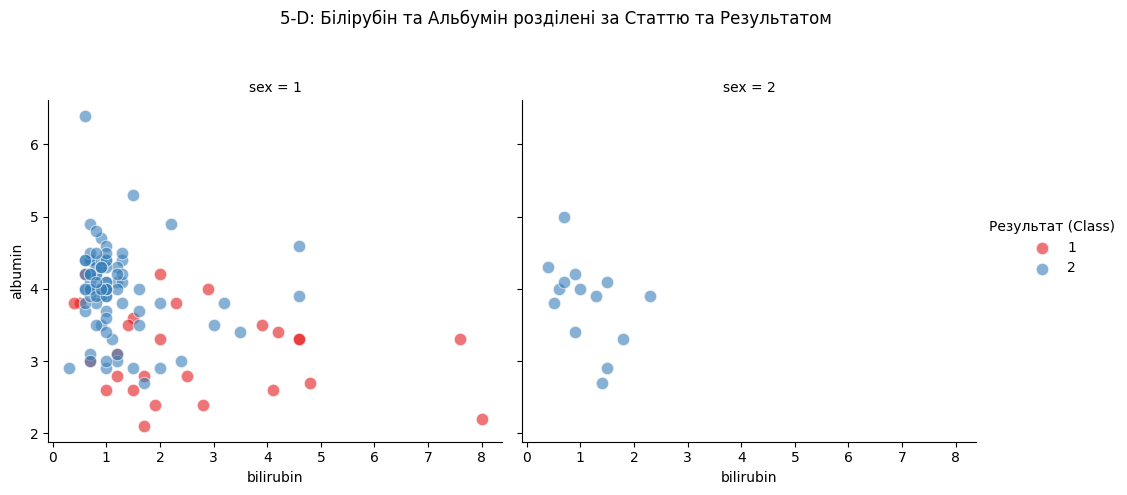

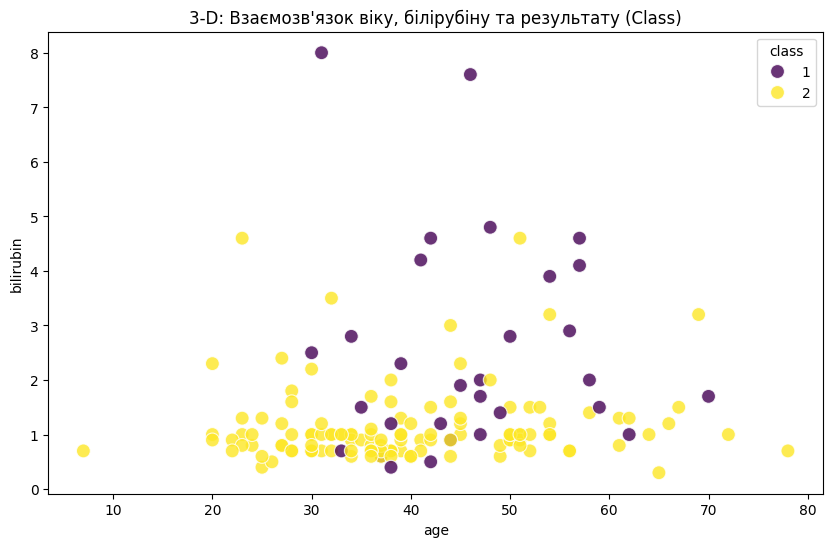

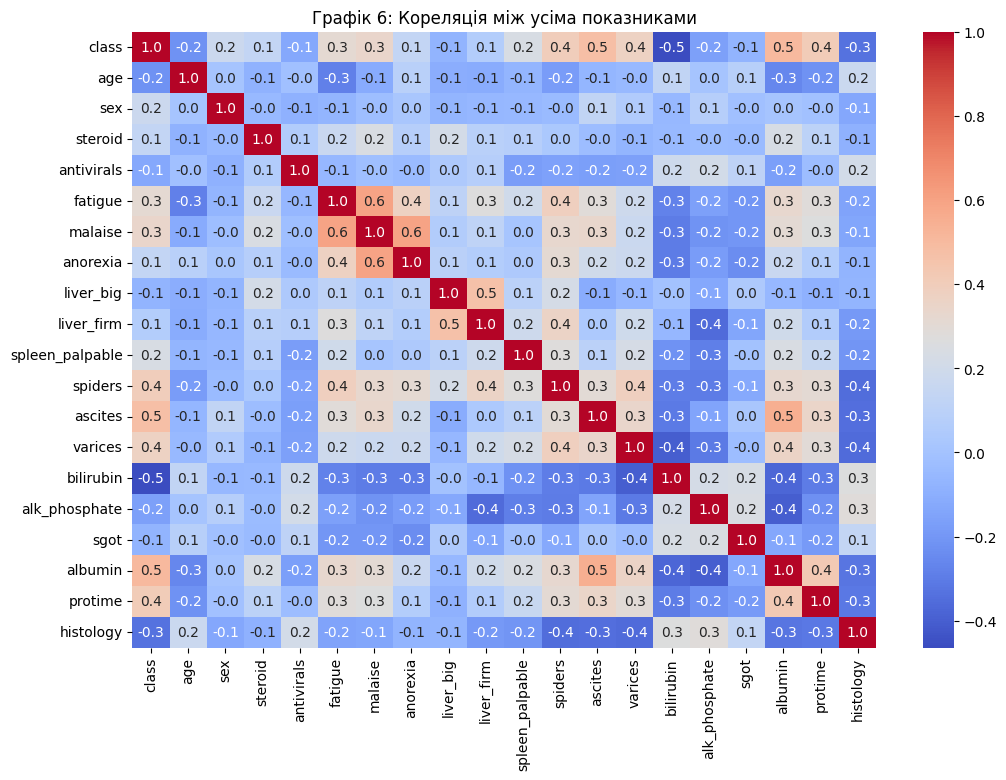

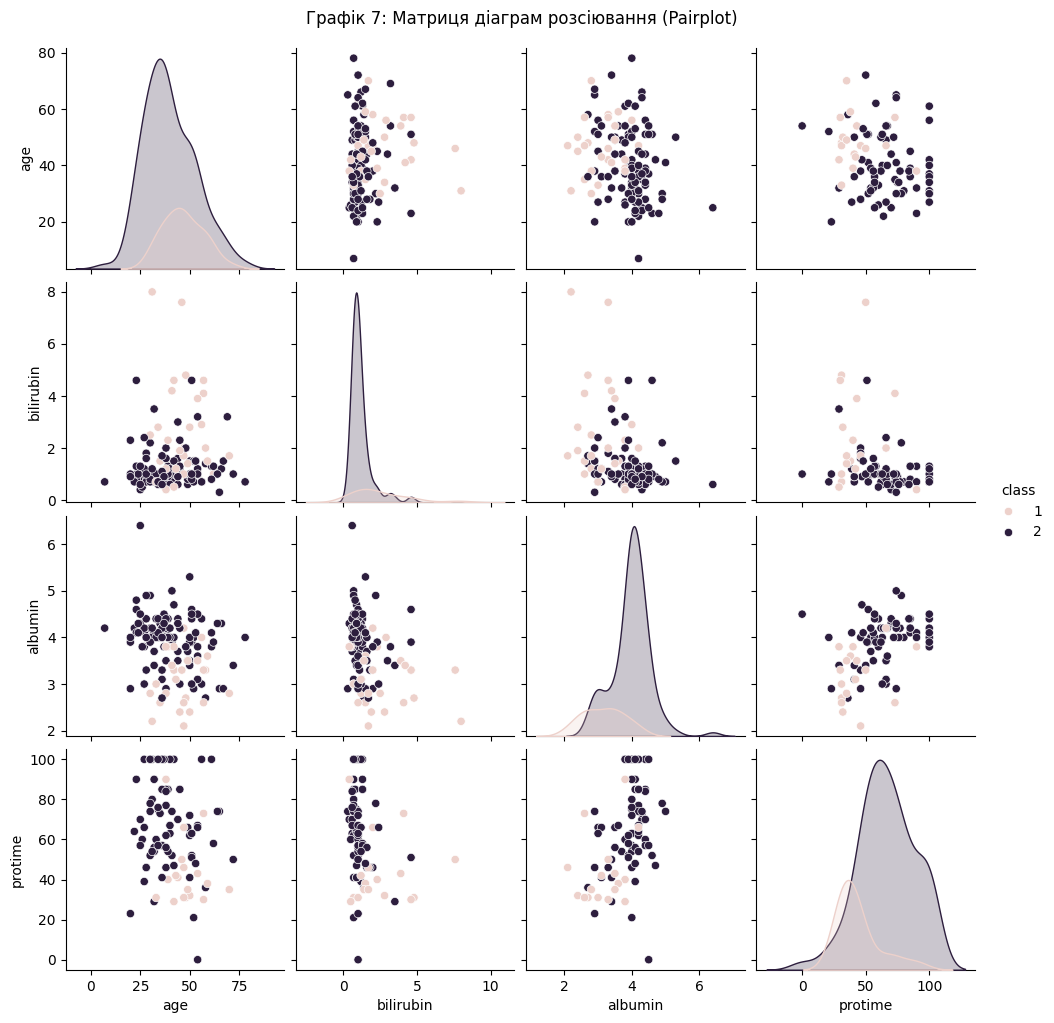

In [31]:
#робимо складний графік розділений на панелі за статтю пацієнтів
g = sns.FacetGrid(df, col="sex", hue="class", palette="Set1", height=5)
g.map(sns.scatterplot, "bilirubin", "albumin", s=80, alpha=0.6)

g.add_legend(title="Результат (Class)")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('5-D: Білірубін та Альбумін розділені за Статтю та Результатом')
plt.show()

#створюємо точкову діаграму для трьох вимірів де колір показує клас
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='bilirubin', hue='class', 
                palette='viridis', s=100, alpha=0.8)
plt.title("3-D: Взаємозв'язок віку, білірубіну та результату (Class)")
plt.show()

#будуємо теплову карту для перевірки зв'язків між усіма цифрами
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Графік 6: Кореляція між усіма показниками")
plt.show()

#створюємо матрицю графіків для одночасного порівняння основних ознак
sns.pairplot(df[['age', 'bilirubin', 'albumin', 'protime', 'class']], hue='class')
plt.suptitle("Графік 7: Матриця діаграм розсіювання (Pairplot)", y=1.02)
plt.show()

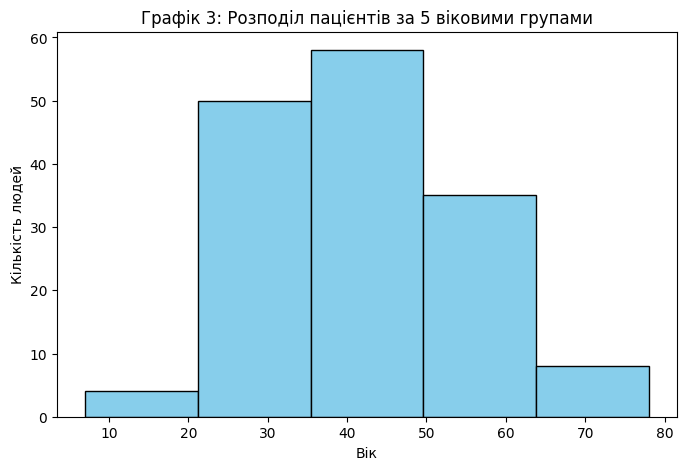

In [32]:
#гістограма розподілу пацієнтів по п'яти вікових групах
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=5, color='skyblue', edgecolor='black')
plt.title("Графік 3: Розподіл пацієнтів за 5 віковими групами")
plt.xlabel("Вік")
plt.ylabel("Кількість людей")
plt.show()

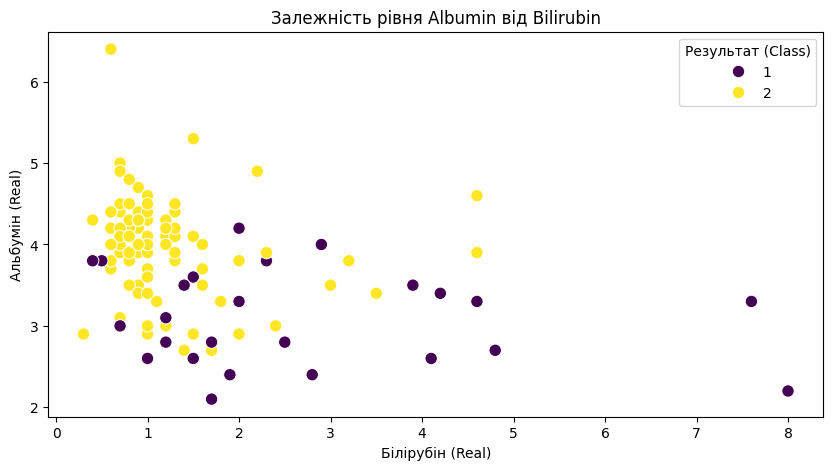

In [33]:
#графік залежності Albumin від Bilirubin
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bilirubin', y='albumin', hue='class', palette='viridis', s=80)

plt.title("Залежність рівня Albumin від Bilirubin")
plt.xlabel("Білірубін (Real)")
plt.ylabel("Альбумін (Real)")
plt.legend(title='Результат (Class)')
plt.show()

In [34]:
#заповнюємо пусті клітинки в числових колонках середнім або медіаною
df['bilirubin'] = df['bilirubin'].fillna(df['bilirubin'].mean())
df['albumin'] = df['albumin'].fillna(df['albumin'].mean())
df['protime'] = df['protime'].fillna(df['protime'].median())
df['alk_phosphate'] = df['alk_phosphate'].fillna(df['alk_phosphate'].median())

#шукаємо колонки з категоріями
categorical_cols = ['steroid', 'fatigue', 'malaise', 'anorexia', 'liver_big', 
                    'liver_firm', 'spleen_palpable', 'spiders', 'ascites', 'varices']
#замінюємо пусті місця в категоріях на значення що зустрічається найчастіше
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Пропуски після повного очищення:", df.isnull().sum().sum())

Пропуски після повного очищення: 4


In [35]:
import pandas as pd#пандас для роботи з таблицями та аналізу даних
import numpy as np#нампай для математичних операцій та роботи з масивами
import seaborn as sns#сіборн для створення красивих статистичних графіків
import matplotlib.pyplot as plt#матплотліб для візуалізації та налаштування малюнків

# завантажуємо дані безпосередньо з репозиторію UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/hepatitis/hepatitis.data"
columns = [
    'class', 'age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia', 
    'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites', 'varices', 
    'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime', 'histology'
]
df = pd.read_csv(url, names=columns, na_values='?')
#читаємо файл та вказуємо що знак питання це пусте значення
print("Перші 5 рядків датасету:")
df.head(10)

Перші 5 рядків датасету:


,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology
0,2,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,2,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,2,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1
5,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.9,95.0,28.0,4.0,75.0,1
6,1,51,1,1.0,2,1.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1
7,2,23,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,1
8,2,39,1,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,0.7,NaN,48.0,4.4,NaN,1
9,2,30,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,120.0,3.9,NaN,1


lab3